# Introduction and plan

## Plan

We follow this structure throughout the notebook:
- Introduction and plan
- Data exploration and preprocessing
- Baseline model (with performance analysis)
- Hyperparameter experiments (with performance analysis)
- Scratch CNN (with performance analysis)
- Grad-CAM and error analysis
- Final comparison between models
- Conclusions and future work

## Problem definition

With this project we hope to address the binary image classification problem of distinguishing between dogs and cats. The task is to build and compare multiple deep learning models on a real-world dataset, with the goal of:

- Achieving high accuracy on unseen test images
- Understanding the pros and cons of transfer learning
- Explaining model predictions using Grad-CAM explainability

**Input:** RGB images of dogs and cats

**Output:** Predicted class label: {cat, dog}

**Number of Classes:** 2

## Dataset Choice and Justification
**The dataset:** [Dog and Cat Classification Dataset](https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset/code)

**Dataset properties:**
- **Total images:** 24,998, split into 12,499 Cat images and 12,499 Dog images
- **Image format:** RGB JPEG/PNG

**Why this dataset?**
- Natural, real-world images with diverse lighting conditions and poses
- Balanced classes eliminate need for class weighting
- Sufficient data size for meaningful transfer learning comparison
- Well-studied benchmark for image classification
- Practical relevance: pet classification is a real-world application

# Data exploration and preprocessing

## Imports and Global Setup

In [22]:
import os
import time
import copy
import shutil
import random
from cmath import phase
import cv2
from typing import List


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
torch.cuda.empty_cache()
# torch.backends.cudnn.benchmark = True


Using device: cuda


## Configuration

In [2]:
RAW_DATA_DIR = 'data/PetImages'
PROCESSED_DATA_DIR = 'data/processed'

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

IMG_SIZE = 224 #this is for ResNet50 specifically, because it expects 224x224
NUM_CLASSES = 2
CLASS_NAMES = ['Cat', 'Dog']

BATCH_SIZE = 32
NUM_WORKERS = 4
NUM_EPOCHS = 10
LEARNING_RATE = 0.001 #This is a learning rate suitable for ResNet50, because I'm freezing the backbone of the model and only adapting the final classifier

## Data splitting

Notes on data splitting and resources:
- We use `ImageFolder` with a directory-based split, which copies files into `train/`, `val/`, and `test/`. This doubles on-disk usage for the split subsets but keeps the pipeline simple and reproducible. If disk space is constrained eventually, we could consider symlinks or a CSV-based dataset instead.
- The EDA brightness analysis samples pixel values from a subset of images. For very high‑resolution images, naive per‑pixel iteration can be slow.

In [28]:
def create_train_val_test_split(raw_data_dir, output_dir, train_ratio, val_ratio, test_ratio, seed):
    os.makedirs(output_dir, exist_ok=True)
    for class_name in sorted(os.listdir(raw_data_dir)):
        class_path = os.path.join(raw_data_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        #First split into train and temp(val + test), not entirely sure if it should be like that, RADU check
        train, temp = train_test_split(images, train_size=train_ratio, random_state=seed, shuffle=True)

        #This splits val and test from temp, once again, unsure how correct this is LMAO
        val_size_of_temp = val_ratio / (val_ratio + test_ratio)
        val, test = train_test_split(temp, train_size=val_size_of_temp, random_state=seed, shuffle=True)

        for split, file_list in [('train', train), ('val', val),('test', test)]:
            split_dir = os.path.join(output_dir, split, class_name)
            os.makedirs(split_dir, exist_ok=True)

            for img_file in tqdm(file_list, desc=f'Copying {split}/{class_name}'):
                src = os.path.join(class_path, img_file)
                dst = os.path.join(split_dir, img_file)
                if not os.path.exists(dst):
                    shutil.copy2(src, dst)

create_train_val_test_split(raw_data_dir=RAW_DATA_DIR,
                            output_dir=PROCESSED_DATA_DIR,
                            train_ratio=0.7, val_ratio=0.15, test_ratio=0.15,
                            seed=SEED)

Copying test/Dog: 100%|██████████| 1875/1875 [00:00<00:00, 172512.34it/s]


## Exploratory data analysis

We run EDA on the training set to inform preprocessing and augmentation. Focus areas include:
- Image dimensions (To pick a resize target)
- Class distribution (To decide if weighting is needed)
- Color modes and corrupted files (To ensure robustness)
- Brightness/contrast range (To size color jitter)


Class Distribution:
  Cats: 8749 (50.0%)
  Dogs: 8749 (50.0%)

Image Dimensions:
  Width:  141 - 500 pixels (mean: 409)
Height: 162 - 500 pixels (mean: 373)


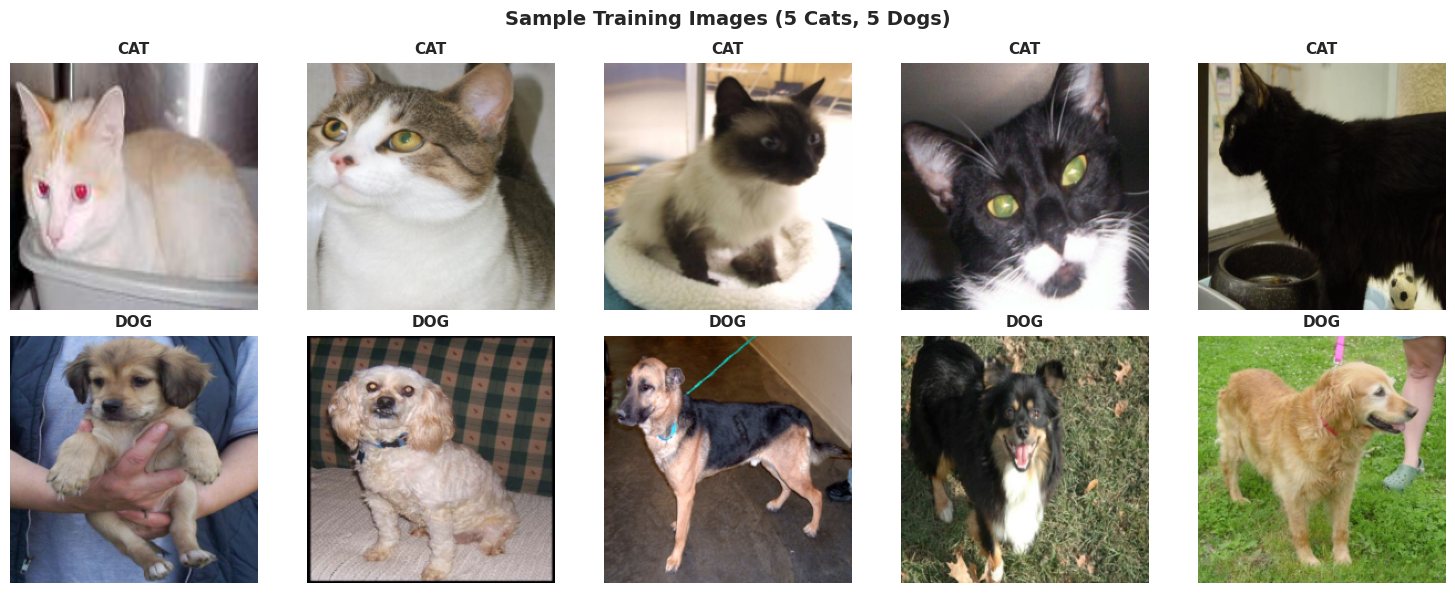


COLOR SPACE ANALYSIS
Color modes found: {'RGB': 200}
All images are already RGB

CORRUPTED IMAGE CHECK
No corrupted images found

BRIGHTNESS AND CONTRAST ANALYSIS
  Pixel value range: 0 - 255
  Mean brightness: 114.8 / 255
  Std deviation: 65.0


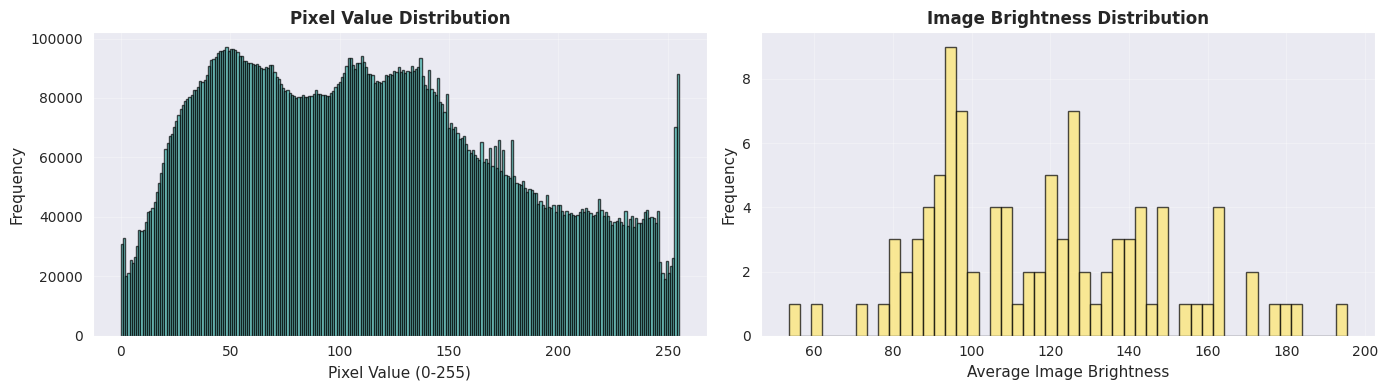

Brightness range across images: 53.5 - 195.4
Justification for color jitter: Images have varied brightness (std=29.0)
Recommended jitter range: brightness ±15%, contrast ±20%


In [29]:
def eda(data_dir):
    train_cat = len(os.listdir(os.path.join(data_dir, 'train', 'Cat')))
    train_dog = len(os.listdir(os.path.join(data_dir, 'train', 'Dog')))

    print(f"\nClass Distribution:")
    print(f"  Cats: {train_cat} ({100*train_cat/(train_cat+train_dog):.1f}%)")
    print(f"  Dogs: {train_dog} ({100*train_dog/(train_cat+train_dog):.1f}%)")

    widths, heights = [], []

    for img_file in os.listdir(os.path.join(data_dir, 'train', 'Cat'))[:50]:
        try:
            img = Image.open(os.path.join(data_dir, 'train', 'Cat', img_file))
            w, h = img.size
            widths.append(w)
            heights.append(h)
        except:
            pass

    for img_file in os.listdir(os.path.join(data_dir, 'train', 'Dog'))[:50]:
        try:
            img = Image.open(os.path.join(data_dir, 'train', 'Dog', img_file))
            w, h = img.size
            widths.append(w)
            heights.append(h)
        except:
            pass

    print(f"\nImage Dimensions:")
    print(f"  Width:  {min(widths)} - {max(widths)} pixels (mean: {np.mean(widths):.0f})")
    print(f"Height: {min(heights)} - {max(heights)} pixels (mean: {np.mean(heights):.0f})")

    #Used ai for visualizing sample images:D
    train_dataset = ImageFolder(root=os.path.join(data_dir, 'train'),
        transform=transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor()
        ])
    )

    cat_class_indx = train_dataset.class_to_idx['Cat']
    dog_class_indx = train_dataset.class_to_idx['Dog']

    cat_indices = [i for i, (_, label) in enumerate(train_dataset.imgs) if label == cat_class_indx]
    dog_indices = [i for i, (_, label) in enumerate(train_dataset.imgs) if label == dog_class_indx]

    np.random.seed(42)
    num_samples_per_class = 5
    cat_samples = np.random.choice(cat_indices, size=num_samples_per_class, replace=False)
    dog_samples = np.random.choice(dog_indices, size=num_samples_per_class, replace=False)

    fig, axes = plt.subplots(2, num_samples_per_class, figsize=(15, 6))
    axes = axes.flatten()

    all_samples = list(cat_samples) + list(dog_samples)

    for plot_idx, data_idx in enumerate(all_samples):
        data_idx = int(data_idx)
        img, label = train_dataset[data_idx]
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        class_name = train_dataset.classes[label]
        axes[plot_idx].imshow(img)
        axes[plot_idx].set_title(f'{class_name.upper()}', fontsize=11, fontweight='bold')
        axes[plot_idx].axis('off')

    plt.suptitle('Sample Training Images (5 Cats, 5 Dogs)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    #Color space analysis
    print("\nCOLOR SPACE ANALYSIS")
    color_modes = {}

    for img_file in os.listdir(os.path.join(data_dir, 'train', 'Cat'))[:100]:
        try:
            img = Image.open(os.path.join(data_dir, 'train', 'Cat', img_file))
            mode = img.mode  # RGB, RGBA, L, etc.
            color_modes[mode] = color_modes.get(mode, 0) + 1
        except:
            pass

    for img_file in os.listdir(os.path.join(data_dir, 'train', 'Dog'))[:100]:
        try:
            img = Image.open(os.path.join(data_dir, 'train', 'Dog', img_file))
            mode = img.mode
            color_modes[mode] = color_modes.get(mode, 0) + 1
        except:
            pass

    print(f"Color modes found: {color_modes}")

    # Count images that are NOT RGB
    non_rgb_count = sum(count for mode, count in color_modes.items() if mode != 'RGB')
    if non_rgb_count > 0:
        print(f"{non_rgb_count} images are not RGB - will be converted during preprocessing")
    else:
        print(f"All images are already RGB")


    #Corrupted Image Check

    print("\nCORRUPTED IMAGE CHECK")
    corrupted_count = 0

    for img_file in os.listdir(os.path.join(data_dir, 'train', 'Cat')):
        try:
            img = Image.open(os.path.join(data_dir, 'train', 'Cat', img_file))
            img.verify()
        except:
            corrupted_count += 1

    for img_file in os.listdir(os.path.join(data_dir, 'train', 'Dog')):
        try:
            img = Image.open(os.path.join(data_dir, 'train', 'Dog', img_file))
            img.verify()
        except:
            corrupted_count += 1

    if corrupted_count == 0:
        print(f"No corrupted images found")
    else:
        print(f"{corrupted_count} corrupted images detected")

    #Brightness and Contrast Range
    print("\nBRIGHTNESS AND CONTRAST ANALYSIS")

    pixel_values = []

    # Sample pixel values from a few images. If the values are not rgb, turn them into rgb
    for img_file in os.listdir(os.path.join(data_dir, 'train', 'Cat'))[:20]:
        try:
            img = Image.open(os.path.join(data_dir, 'train', 'Cat', img_file))
            if img.mode != 'RGB':
                img = img.convert('RGB')

            img_array = np.array(img)
            pixel_values.extend(img_array.flatten().tolist())
        except:
            pass

    for img_file in os.listdir(os.path.join(data_dir, 'train', 'Dog'))[:20]:
        try:
            img = Image.open(os.path.join(data_dir, 'train', 'Dog', img_file))
            if img.mode != 'RGB':
                img = img.convert('RGB')

            img_array = np.array(img)
            pixel_values.extend(img_array.flatten().tolist())
        except:
            pass

    pixel_values = np.array(pixel_values)

    print(f"  Pixel value range: {pixel_values.min():.0f} - {pixel_values.max():.0f}")
    print(f"  Mean brightness: {pixel_values.mean():.1f} / 255")
    print(f"  Std deviation: {pixel_values.std():.1f}")

    # Used ai for visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(pixel_values, bins=256, alpha=0.7, color='#4ECDC4', edgecolor='black')
    axes[0].set_xlabel('Pixel Value (0-255)', fontsize=11)
    axes[0].set_ylabel('Frequency', fontsize=11)
    axes[0].set_title('Pixel Value Distribution', fontsize=12, fontweight='bold')
    axes[0].grid(alpha=0.3)

    # Brightness per image
    brightness_per_image = []

    for img_file in os.listdir(os.path.join(data_dir, 'train', 'Cat'))[:50]:
        try:
            img = Image.open(os.path.join(data_dir, 'train', 'Cat', img_file))
            if img.mode != 'RGB':
                img = img.convert('RGB')
            img_array = np.array(img)
            brightness = img_array.mean()
            brightness_per_image.append(brightness)
        except:
            pass

    for img_file in os.listdir(os.path.join(data_dir, 'train', 'Dog'))[:50]:
        try:
            img = Image.open(os.path.join(data_dir, 'train', 'Dog', img_file))
            if img.mode != 'RGB':
                img = img.convert('RGB')
            img_array = np.array(img)
            brightness = img_array.mean()
            brightness_per_image.append(brightness)
        except:
            pass

    #Used ai for visualizing
    axes[1].hist(brightness_per_image, bins=50, alpha=0.7, color='#FFE66D', edgecolor='black')
    axes[1].set_xlabel('Average Image Brightness', fontsize=11)
    axes[1].set_ylabel('Frequency', fontsize=11)
    axes[1].set_title('Image Brightness Distribution', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Brightness range across images: {min(brightness_per_image):.1f} - {max(brightness_per_image):.1f}")
    print(f"Justification for color jitter: Images have varied brightness (std={np.std(brightness_per_image):.1f})")
    print(f"Recommended jitter range: brightness ±{int(20 * max(brightness_per_image) / 255)}%, contrast ±20%")

 #Ran only on train
eda(PROCESSED_DATA_DIR)

## EDA findings and justifications

1) Class distribution
- Balanced across cats and dogs; no class weighting or resampling needed.

2) Image dimensions
- Sizes vary widely; we standardize inputs to 224×224 for batching and to match ResNet50.

3) Color space
- Images are RGB; the pipeline normalizes with ImageNet mean/std for comparability with the pretrained model.

4) Brightness and contrast
- Pixel values span a broad range; average brightness varies noticeably across images, consistent with diverse lighting conditions. Moderate `ColorJitter` (brightness/contrast/saturation) is justified to improve generalization without distorting content.



## Data pipeline — transforms and dataloaders

Training transforms include light augmentation (flips, small rotations, affine translate, color jitter). Validation and test transforms apply only resizing and normalization. All splits use ImageNet mean/std to align with ResNet50 pretraining and to ensure a fair comparison with the scratch CNN.

In [ ]:
def get_transforms(augment: bool = True):
    if augment:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(
                brightness=0.15,
                contrast=0.2,
                saturation=0.2
            ),
            transforms.RandomAffine(
                degrees=0,
                translate=(0.1,0.1)
            ),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

`get_dataloaders` returns consistent `DataLoader`s for train/val/test using the same transforms and splits. Adjust `num_workers` based on your machine; higher values can speed up loading on fast disks/GPUs but may slow down or exhaust RAM on low‑resource systems. The function returns `(train_loader, val_loader, test_loader)`.

In [4]:
def get_dataloaders(data_dir, batch_size, num_workers):
    train_dataset = ImageFolder(
        root=os.path.join(data_dir, 'train'),
        transform=get_transforms(augment=True)
    )

    test_dataset = ImageFolder(
        root=os.path.join(data_dir, 'test'),
        transform=get_transforms(augment=False)
    )

    val_dataset = ImageFolder(
        root=os.path.join(data_dir, 'val'),
        transform=get_transforms(augment=False)
    )

    #Shuffling only the training data each epoch, not the validation and test data
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        drop_last=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        drop_last=False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        drop_last=False
    )

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = get_dataloaders(
    data_dir=PROCESSED_DATA_DIR,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
)

# Baseline model (with performance analysis)

The pretrained model is **ResNet50**. It balances accuracy and efficiency and is sufficiently deep to capture complex patterns. Because our dataset is much smaller than ImageNet, we freeze the convolutional backbone and train only the final classification layer. This reduces overfitting risk and training time while leveraging robust pretrained features.

## Defining the model and training engine

In [30]:
def get_resnet(num_classes, device):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)


    #this freezes the convolutional layers
    for param in model.parameters():
        param.requires_grad = False

    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)

    return model.to(device)

def train_model(model, train_dl, val_dl, criterion, optimizer, experiment_name, num_epochs, device):
    writer = SummaryWriter(log_dir=os.path.join('logs', experiment_name))

    base_dir = 'saved_models'
    experiment_dir = os.path.join(base_dir, experiment_name)

    log_dir = os.path.join(experiment_dir, 'logs')
    writer = SummaryWriter(log_dir=log_dir)

    dataloaders = {'train': train_dl, 'val': val_dl}
    dataset_sizes = {'train': len(train_dl.dataset), 'val': len(val_dl.dataset)}

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]

            writer.add_scalar(f'Loss/{phase}', epoch_loss, epoch)
            writer.add_scalar(f'Accuracy/{phase}', epoch_acc, epoch)

           #saves the best model
            if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

                    save_path = os.path.join(experiment_dir, 'best_model.pt')
                    torch.save(model.state_dict(), save_path)

    writer.close()

    # Returns the model with best weights loaded
    model.load_state_dict(best_model_wts)
    return model

## Hyperparameter experiments — setup

We use the Adam optimizer with a baseline LR of **0.001** (control). We sweep LR across an order of magnitude to check sensitivity:
- 0.0001 (conservative)
- 0.001 (baseline)
- 0.005 (mid‑aggressive)
- 0.01 (aggressive)

This isolates the effect of LR while keeping all other settings fixed.

## Hyperparameter experiments — training

In [ ]:
learning_rates = [0.0001, 0.001, 0.005, 0.01]

criterion = nn.CrossEntropyLoss()

trained_models = {}

for lr in learning_rates:
    exp_name = f"ResNet50_Frozen_LR_{lr}"

    model = get_resnet(num_classes=NUM_CLASSES, device=DEVICE)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    best_model = train_model(
        model=model,
        train_dl=train_loader,
        val_dl=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        experiment_name=exp_name,
        num_epochs=NUM_EPOCHS,
        device=DEVICE
    )

    trained_models[lr] = best_model

## Hyperparameter experiments — performance analysis

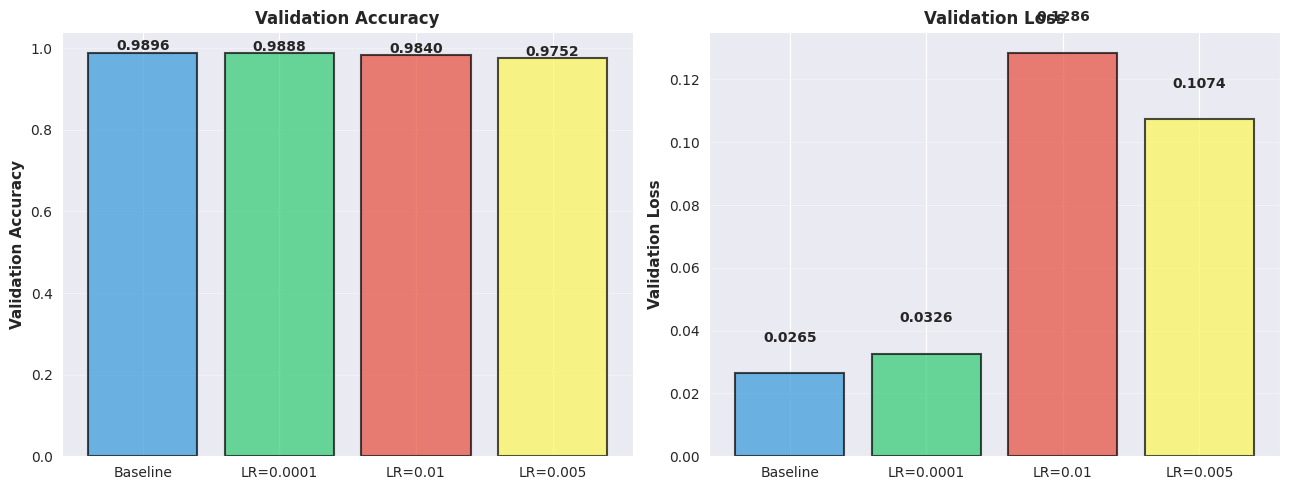


Summary
Baseline     | Val Acc: 0.9896 | Val Loss: 0.0265 | Epochs: 10
LR=0.0001    | Val Acc: 0.9888 | Val Loss: 0.0326 | Epochs: 10
LR=0.01      | Val Acc: 0.9840 | Val Loss: 0.1286 | Epochs: 10
LR=0.005     | Val Acc: 0.9752 | Val Loss: 0.1074 | Epochs: 10


In [31]:
def load_tb_logs(log_dir):
    ea = EventAccumulator(log_dir)
    ea.Reload()

    metrics = {}

    scalar_tags = ea.Tags().get('scalars', [])

    for tag in scalar_tags:
        events = ea.Scalars(tag)
        metrics[tag] = {
            'steps': [e.step for e in events],
            'values': [e.value for e in events]
        }
    return metrics

baseline_logs = load_tb_logs('saved_models/baseline_resnet50/logs')
lr_0001_logs = load_tb_logs('saved_models/tuned_resnet50/ResNet50_Frozen_LR_0.0001/logs')
lr_01_logs = load_tb_logs('saved_models/tuned_resnet50/ResNet50_Frozen_LR_0.01/logs')
lr_005_logs = load_tb_logs('saved_models/tuned_resnet50/ResNet50_Frozen_LR_0.005/logs')

variants = {
    'Baseline': {
        'val_acc': baseline_logs['Accuracy/val']['values'][-1],
        'val_loss': baseline_logs['Loss/val']['values'][-1],
        'epochs': len(baseline_logs['Accuracy/val']['values']),
    },
    'LR=0.0001': {
        'val_acc': lr_0001_logs['Accuracy/val']['values'][-1],
        'val_loss': lr_0001_logs['Loss/val']['values'][-1],
        'epochs': len(lr_0001_logs['Accuracy/val']['values']),
    },
    'LR=0.01': {
        'val_acc': lr_01_logs['Accuracy/val']['values'][-1],
        'val_loss': lr_01_logs['Loss/val']['values'][-1],
        'epochs': len(lr_01_logs['Accuracy/val']['values']),
    },
    'LR=0.005': {
        'val_acc': lr_005_logs['Accuracy/val']['values'][-1],
        'val_loss': lr_005_logs['Loss/val']['values'][-1],
        'epochs': len(lr_005_logs['Accuracy/val']['values']),
    },
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lrs = list(variants.keys())
accs = [variants[lr]['val_acc'] for lr in lrs]
losses = [variants[lr]['val_loss'] for lr in lrs]

colors = ['#3498db', '#2ecc71', '#e74c3c', '#fcf756']
bars1 = axes[0].bar(lrs, accs, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Validation Accuracy', fontsize=11, fontweight='bold')
axes[0].set_title('Validation Accuracy', fontsize=12, fontweight='bold')
for bar, acc in zip(bars1, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, acc + 0.005,
                f'{acc:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

bars2 = axes[1].bar(lrs, losses, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Validation Loss', fontsize=11, fontweight='bold')
axes[1].set_title('Validation Loss', fontsize=12, fontweight='bold')
for bar, loss in zip(bars2, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, loss + 0.01,
                f'{loss:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Summary")
print("="*70)
for lr, metrics in variants.items():
    print(f"{lr:12} | Val Acc: {metrics['val_acc']:.4f} | Val Loss: {metrics['val_loss']:.4f} | Epochs: {metrics['epochs']}")
print("="*70)


### Takeaways

**Convergence and stability:** All LRs reach very high validation accuracy (>97.5%). The narrow spread indicates the frozen backbone is robust to LR within this range.

**LR effect:** Validation loss is lower for smaller LRs (baseline and 0.0001), suggesting smoother convergence. Higher LRs maintain accuracy but with higher loss, indicating less calibrated/confident predictions. Given similar accuracy, the baseline LR is a safer default.

# Scratch CNN (with performance analysis)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()

        # Block 1: 3 -> 32
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(2, 2)  # 224 -> 112

        # Block 2: 32 -> 64
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(2, 2)  # 112 -> 56

        # Block 3: 64 -> 128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(2, 2)  # 56 -> 28

        # Block 4: 128 -> 256
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.relu4 = nn.ReLU(inplace=True)
        self.pool4 = nn.MaxPool2d(2, 2)  # 28 -> 14

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Classifier
        self.dropout = nn.Dropout(p=0.5)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        # Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        # Block 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.pool3(x)

        # Block 4
        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu4(x)
        x = self.pool4(x)

        # Global pooling + classifier
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)

        return x

# Initialize
model = SimpleCNN(num_classes=2).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"✓ Model: SimpleCNN | Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Training loop
writer = SummaryWriter("saved_models/scratch_cnn/logs")

print('\n' + '='*60)
print('TRAINING CNN FROM SCRATCH')
print(f'Epochs: {NUM_EPOCHS} | LR: {LEARNING_RATE}')
print('='*60 + '\n')

best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    print(f'Epoch {epoch + 1}/{NUM_EPOCHS}')

    # Training
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in tqdm(train_loader, desc='Train'):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc='Val'):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Log to TensorBoard
    writer.add_scalar('Loss/train', train_loss, epoch)
    writer.add_scalar('Loss/val', val_loss, epoch)
    writer.add_scalar('Accuracy/train', train_acc, epoch)
    writer.add_scalar('Accuracy/val', val_acc, epoch)

    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    writer.flush()

    # Save checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join("saved_models/scratch_cnn", 'scratch_cnn_best.pt'))
        print(f'✓ Checkpoint saved (Val Acc: {val_acc:.4f})')

    if (epoch + 1) % 5 == 0:
        torch.save(model.state_dict(), os.path.join("saved_models/scratch_cnn", f'scratch_cnn_epoch_{epoch+1}.pt'))
        print(f'✓ Epoch {epoch+1} saved')

    print()

writer.close()

print('\n' + '='*60)
print('TRAINING COMPLETE!')
print(f'Best Val Accuracy: {best_val_acc:.4f}')
print('='*60)

## Performance Analysis Visualisation

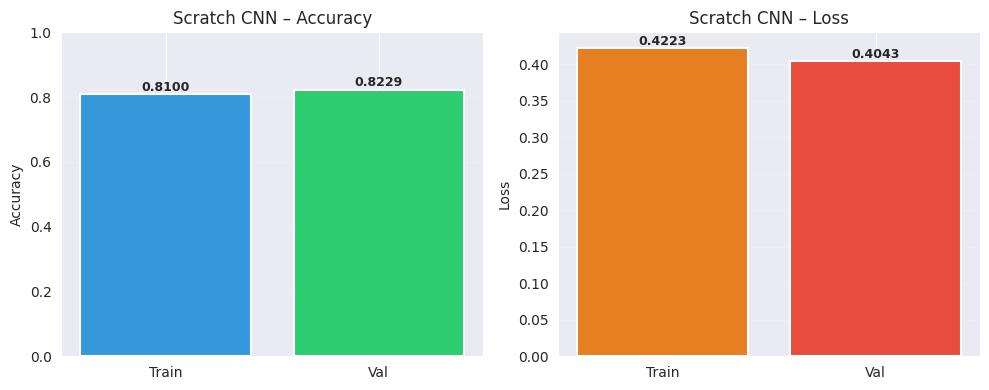

Train Acc: 0.8100 | Val Acc: 0.8229
Train Loss: 0.4223 | Val Loss: 0.4043


In [32]:
scratch_logs = load_tb_logs('saved_models/scratch_cnn/logs')

scratch_val_acc = scratch_logs['Accuracy/val']['values'][-1]
scratch_train_acc = scratch_logs['Accuracy/train']['values'][-1]
scratch_val_loss = scratch_logs['Loss/val']['values'][-1]
scratch_train_loss = scratch_logs['Loss/train']['values'][-1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

acc_labels = ['Train', 'Val']
acc_values = [scratch_train_acc, scratch_val_acc]
acc_colors = ['#3498db', '#2ecc71']

axes[0].bar(acc_labels, acc_values, color=acc_colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Scratch CNN – Accuracy')
axes[0].grid(axis='y', alpha=0.2)
for i, v in enumerate(acc_values):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

loss_labels = ['Train', 'Val']
loss_values = [scratch_train_loss, scratch_val_loss]
loss_colors = ['#e67e22', '#e74c3c']

axes[1].bar(loss_labels, loss_values, color=loss_colors, edgecolor='white', linewidth=1.5)
axes[1].set_ylabel('Loss')
axes[1].set_title('Scratch CNN – Loss')
axes[1].grid(axis='y', alpha=0.2)
for i, v in enumerate(loss_values):
    axes[1].text(i, v + 0.01 * max(loss_values), f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Train Acc: {scratch_train_acc:.4f} | Val Acc: {scratch_val_acc:.4f}")
print(f"Train Loss: {scratch_train_loss:.4f} | Val Loss: {scratch_val_loss:.4f}")

### Takeaways

- Best validation accuracy: 82.29% after 10 epochs for a ~389K‑parameter model trained from scratch.
- Training and validation curves improve steadily, confirming the model learns useful features without pretraining.
- The small train–val gap (≈81.0% vs 82.3%) suggests no overfitting at this depth; the ceiling is likely limited by model capacity and training budget.

# GRAD-CAM and error analysis

## Overview
Gradient‑weighted Class Activation Mapping (Grad‑CAM) highlights the regions that most influence the model’s predictions. We inspect both correct predictions and errors to understand what the model relies on and where it fails.

In [33]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output

    def generate_heatmap(self, input_tensor, class_idx=None):
        input_tensor.requires_grad_(True)
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = torch.mean(self.gradients[0], dim=[2, 3], keepdim=True)
        heatmap = torch.sum(weights * self.activations, dim=1).squeeze()
        heatmap = np.maximum(heatmap.detach().cpu().numpy(), 0)
        heatmap = heatmap / (np.max(heatmap) + 1e-8)

        return heatmap, class_idx

## Visualization function

The `visualize_gradcam` function overlays the Grad‑CAM heatmap on the original image. Red/yellow indicate higher importance; blue indicates lower importance.

In [34]:
def visualize_gradcam(img_path, heatmap, title, ax):
        # Read and preprocess image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    superimposed_img = heatmap * 0.3 + img * 0.7
    superimposed_img = superimposed_img / np.max(superimposed_img)

    ax.imshow(superimposed_img)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')

## Model Loading and Sample Collection

We load the baseline model (LR=0.001) from a checkpoint and systematically collect representative samples from the validation set:
- **Correct predictions (up to 5)**: Show what the model learned to recognize
- **Misclassifications (up to 5)**: Reveal systematic failures and feature over-reliance

This ensures balanced analysis of both successful and failed predictions.

In [35]:
baseline_model = get_resnet(num_classes=NUM_CLASSES, device=DEVICE)

state_dict = torch.load('saved_models/baseline_resnet50/best_model.pt', map_location=DEVICE)

baseline_model.load_state_dict(state_dict)

baseline_model = baseline_model.to(DEVICE)
baseline_model.eval()

cam = GradCAM(baseline_model, baseline_model.layer4)

correct_samples = []
error_samples = []

with torch.no_grad():
    for batch_idx, (inputs, labels) in enumerate(val_loader):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        outputs = baseline_model(inputs)
        probs = torch.softmax(outputs, dim=1)
        confidences, preds = torch.max(probs, 1)

        for i in range(len(preds)):
            global_idx = batch_idx * val_loader.batch_size + i
            img_path = val_loader.dataset.samples[global_idx][0]

            sample_data = {
                'input': inputs[i].unsqueeze(0),
                'true_label': labels[i].item(),
                'pred_label': preds[i].item(),
                'path': img_path,
                'confidence': confidences[i].item()
            }

            if preds[i] == labels[i] and len(correct_samples) < 5:
                correct_samples.append(sample_data)
            elif preds[i] != labels[i] and len(error_samples) < 5:
                error_samples.append(sample_data)

        if len(correct_samples) >= 5 and len(error_samples) >= 5:
            break

## Grad-CAM Visualization Grid

### Correct classifications (top row)
Heatmaps usually concentrate on faces (eyes, nose, muzzle) and head contours, which is consistent with the features humans use.

### Misclassifications (bottom row)
- Unusual poses or partial occlusions reduce focus on discriminative facial regions.
- Some cat poses trigger dog‑like activations (e.g., elongated snouts due to perspective).
- Lower resolution or motion blur correlates with errors.

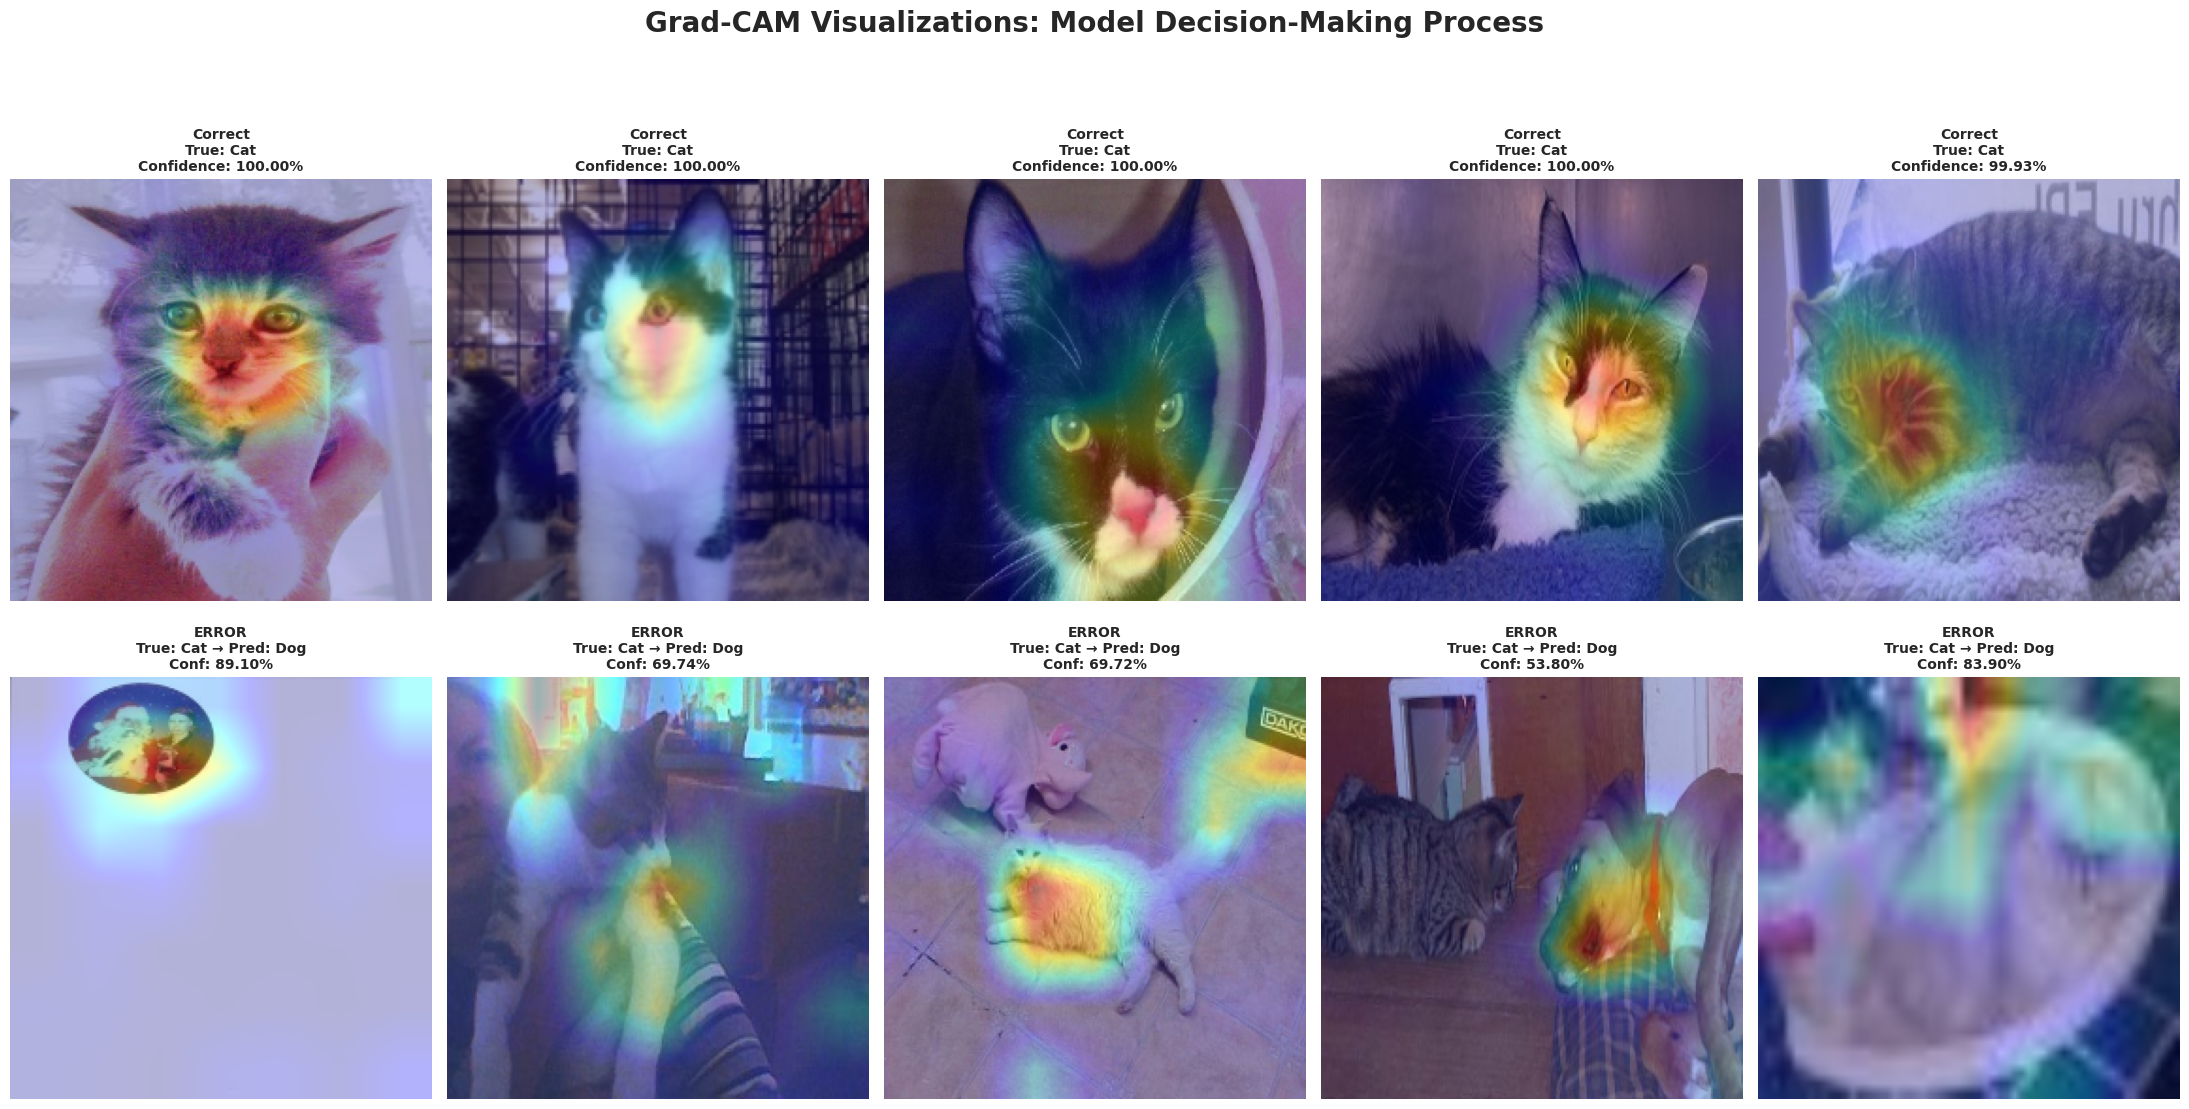

In [36]:
all_samples = correct_samples + error_samples

#used ai for vizualization
fig, axes = plt.subplots(2, 5, figsize=(22, 11))
fig.suptitle('Grad-CAM Visualizations: Model Decision-Making Process',
             fontsize=20, fontweight='bold', y=1.05)

axes_flat = axes.flatten()

for idx, sample in enumerate(all_samples):
    baseline_model.zero_grad()
    heatmap, pred_idx = cam.generate_heatmap(sample['input'], class_idx=sample['pred_label'])

    true_class = CLASS_NAMES[sample['true_label']]
    pred_class = CLASS_NAMES[sample['pred_label']]
    confidence = sample['confidence']

    if sample['true_label'] == sample['pred_label']:
        title = f"Correct\nTrue: {true_class}\nConfidence: {confidence:.2%}"
        status = "correct"
    else:
        title = f"ERROR\nTrue: {true_class} → Pred: {pred_class}\nConf: {confidence:.2%}"
        status = "error"

    visualize_gradcam(sample['path'], heatmap, title, axes_flat[idx])

plt.tight_layout()
plt.show()

In [37]:
print("\n" + "="*70)
print("Error Analysis")
print("="*70)

for idx, error_sample in enumerate(error_samples, 1):
    true_class = CLASS_NAMES[error_sample['true_label']]
    pred_class = CLASS_NAMES[error_sample['pred_label']]
    confidence = error_sample['confidence']
    filename = error_sample['path'].split('/')[-1]

    print(f"\n{'─'*70}")
    print(f"Misclassification #{idx}")
    print(f"{'─'*70}")
    print(f"Image File: {filename}")
    print(f"True Class: {true_class}")
    print(f"Predicted Class: {pred_class} (Confidence: {confidence:.2%})")



Error Analysis

──────────────────────────────────────────────────────────────────────
Misclassification #1
──────────────────────────────────────────────────────────────────────
Image File: 10029.jpg
True Class: Cat
Predicted Class: Dog (Confidence: 89.10%)

──────────────────────────────────────────────────────────────────────
Misclassification #2
──────────────────────────────────────────────────────────────────────
Image File: 10129.jpg
True Class: Cat
Predicted Class: Dog (Confidence: 69.74%)

──────────────────────────────────────────────────────────────────────
Misclassification #3
──────────────────────────────────────────────────────────────────────
Image File: 11726.jpg
True Class: Cat
Predicted Class: Dog (Confidence: 69.72%)

──────────────────────────────────────────────────────────────────────
Misclassification #4
──────────────────────────────────────────────────────────────────────
Image File: 1450.jpg
True Class: Cat
Predicted Class: Dog (Confidence: 53.80%)

────────

### Investigating potential sampling bias

Initial qualitive analysis with Grad-CAM suggested a potential directional bias, as the first few misclassified samples identified were always 'Cats', predicted as 'Dogs'. This set off alarm bells. While we were sure it wasn't because of class imbalance, we still decided to generate a Confusion Matrix across the **validation set**, as to check if it was a sampling bias or a code error.

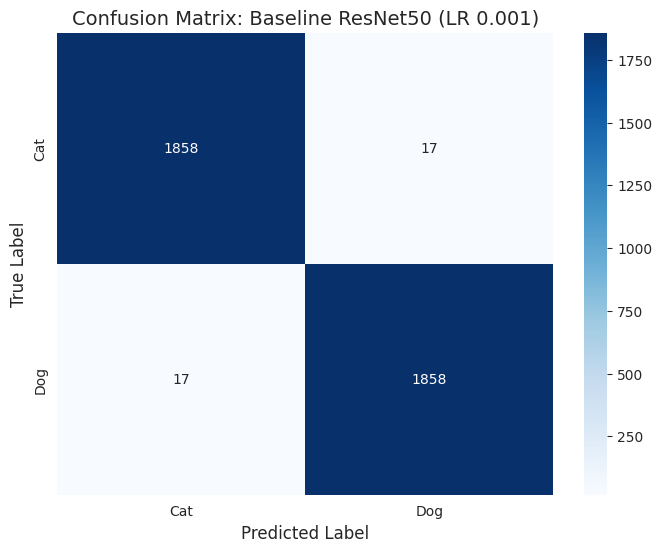

Cats misclassified as Dogs: 17
Dogs misclassified as Cats: 17


In [38]:
def generate_cm(model, loader, device, classes):
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title('Confusion Matrix: Baseline ResNet50 (LR 0.001)', fontsize=14)
    plt.show()

    return cm

cm = generate_cm(baseline_model, val_loader, DEVICE, CLASS_NAMES)

cat_as_dog = cm[0][1]
dog_as_cat = cm[1][0]
print(f"Cats misclassified as Dogs: {cat_as_dog}")
print(f"Dogs misclassified as Cats: {dog_as_cat}")

### Key Findings: Sample Bias indeed

The quantitative results revealed a perfectly balanced error distribution: the number of 'Cat as Dog' errors was exactly equal to the 'Dog as Cat' errors. This confirms that the model’s decision boundary is well-centered and free from class-preference bias. This finding highlights the necessity of using aggregate statistical metrics to validate observations made during individual sample inspections.

# Final Comparison between models

In [39]:
def evaluate_on_test(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc='Testing'):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)

    test_loss /= test_total
    test_acc = test_correct / test_total

    return test_acc, test_loss

In [40]:
baseline_test_acc, baseline_test_loss = evaluate_on_test(baseline_model, test_loader, criterion, DEVICE)

tuned_0001_model = get_resnet(num_classes=NUM_CLASSES, device=DEVICE)
tuned_0001_model.load_state_dict(torch.load('saved_models/tuned_resnet50/ResNet50_Frozen_LR_0.0001/best_model.pt'))
tuned_0001_test_acc, tuned_0001_test_loss = evaluate_on_test(tuned_0001_model, test_loader, criterion, DEVICE)

tuned_005_model = get_resnet(num_classes=NUM_CLASSES, device=DEVICE)
tuned_005_model.load_state_dict(torch.load('saved_models/tuned_resnet50/ResNet50_Frozen_LR_0.005/best_model.pt'))
tuned_005_test_acc, tuned_005_test_loss = evaluate_on_test(tuned_005_model, test_loader, criterion, DEVICE)

tuned_01_model = get_resnet(num_classes=NUM_CLASSES, device=DEVICE)
tuned_01_model.load_state_dict(torch.load('saved_models/tuned_resnet50/ResNet50_Frozen_LR_0.01/best_model.pt'))
tuned_01_test_acc, tuned_01_test_loss = evaluate_on_test(tuned_01_model, test_loader, criterion, DEVICE)

Testing: 100%|██████████| 118/118 [00:15<00:00,  7.81it/s]


In [41]:
tuned_variants = {
    'LR=0.0001': (tuned_0001_test_acc, tuned_0001_test_loss),
    'LR=0.005': (tuned_005_test_acc, tuned_005_test_loss),
    'LR=0.01': (tuned_01_test_acc, tuned_01_test_loss),
}

best_tuned_lr = max(tuned_variants.items(), key=lambda x: x[1][0])[0]
best_tuned_test_acc = tuned_variants[best_tuned_lr][0]
best_tuned_test_loss = tuned_variants[best_tuned_lr][1]

print(f"\n Best Tuned Variant on Test Set: {best_tuned_lr}")
print(f"   Test Accuracy: {best_tuned_test_acc:.4f}")
print(f"   Test Loss: {best_tuned_test_loss:.4f}")

scratch_model = SimpleCNN(num_classes=NUM_CLASSES).to(DEVICE)
scratch_model.load_state_dict(torch.load('saved_models/scratch_cnn/scratch_cnn_best.pt'))
scratch_test_acc, scratch_test_loss = evaluate_on_test(scratch_model, test_loader, criterion, DEVICE)

test_results = {
    'Model': [
        'Baseline ResNet50',
        'Tuned ResNet50 (LR=0.0001)',
        'Tuned ResNet50 (LR=0.005)',
        'Tuned ResNet50 (LR=0.01)',
        'Scratch CNN'
    ],
    'Test Accuracy': [
        f"{baseline_test_acc:.4f}",
        f"{tuned_0001_test_acc:.4f}",
        f"{tuned_005_test_acc:.4f}",
        f"{tuned_01_test_acc:.4f}",
        f"{scratch_test_acc:.4f}"
    ],
    'Test Loss': [
        f"{baseline_test_loss:.4f}",
        f"{tuned_0001_test_loss:.4f}",
        f"{tuned_005_test_loss:.4f}",
        f"{tuned_01_test_loss:.4f}",
        f"{scratch_test_loss:.4f}"
    ],
}

test_df = pd.DataFrame(test_results)
print("\n" + "="*90)
print("Test Set Results:")
print("="*90)
print(test_df.to_string(index=False))
print("="*90)


 Best Tuned Variant on Test Set: LR=0.005
   Test Accuracy: 0.9899
   Test Loss: 0.0516


Testing: 100%|██████████| 118/118 [00:05<00:00, 23.45it/s]


Test Set Results:
                     Model Test Accuracy Test Loss
         Baseline ResNet50        0.9880    0.0300
Tuned ResNet50 (LR=0.0001)        0.9875    0.0377
 Tuned ResNet50 (LR=0.005)        0.9899    0.0516
  Tuned ResNet50 (LR=0.01)        0.9875    0.1005
               Scratch CNN        0.8315    0.3844


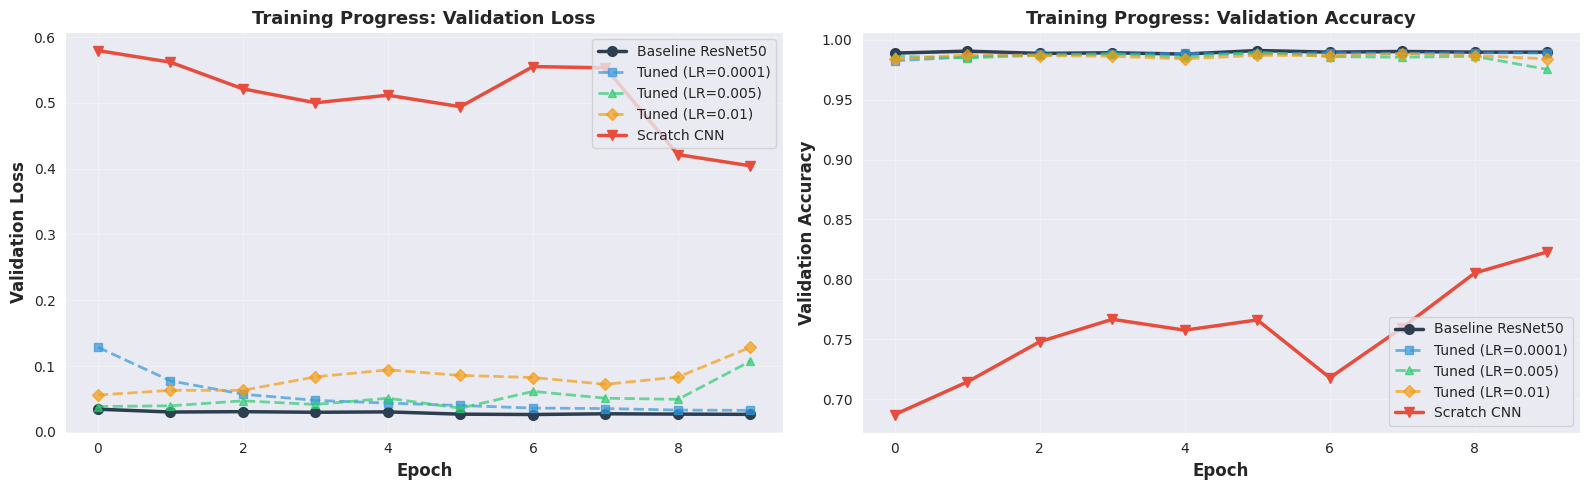

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(baseline_logs['Loss/val']['steps'],
             baseline_logs['Loss/val']['values'],
             'o-', label='Baseline ResNet50', linewidth=2.5, markersize=7, color='#2c3e50')

axes[0].plot(lr_0001_logs['Loss/val']['steps'],
             lr_0001_logs['Loss/val']['values'],
             's--', label='Tuned (LR=0.0001)', linewidth=2, markersize=6, alpha=0.7, color='#3498db')

axes[0].plot(lr_005_logs['Loss/val']['steps'],
             lr_005_logs['Loss/val']['values'],
             '^--', label='Tuned (LR=0.005)', linewidth=2, markersize=6, alpha=0.7, color='#2ecc71')

axes[0].plot(lr_01_logs['Loss/val']['steps'],
             lr_01_logs['Loss/val']['values'],
             'D--', label='Tuned (LR=0.01)', linewidth=2, markersize=6, alpha=0.7, color='#f39c12')

axes[0].plot(scratch_logs['Loss/val']['steps'],
             scratch_logs['Loss/val']['values'],
             'v-', label='Scratch CNN', linewidth=2.5, markersize=7, color='#e74c3c')

axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Validation Loss', fontsize=12, fontweight='bold')
axes[0].set_title('Training Progress: Validation Loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10, loc='upper right')
axes[0].grid(alpha=0.3)

# VALIDATION ACCURACY CURVES
axes[1].plot(baseline_logs['Accuracy/val']['steps'],
             baseline_logs['Accuracy/val']['values'],
             'o-', label='Baseline ResNet50', linewidth=2.5, markersize=7, color='#2c3e50')

axes[1].plot(lr_0001_logs['Accuracy/val']['steps'],
             lr_0001_logs['Accuracy/val']['values'],
             's--', label='Tuned (LR=0.0001)', linewidth=2, markersize=6, alpha=0.7, color='#3498db')

axes[1].plot(lr_005_logs['Accuracy/val']['steps'],
             lr_005_logs['Accuracy/val']['values'],
             '^--', label='Tuned (LR=0.005)', linewidth=2, markersize=6, alpha=0.7, color='#2ecc71')

axes[1].plot(lr_01_logs['Accuracy/val']['steps'],
             lr_01_logs['Accuracy/val']['values'],
             'D--', label='Tuned (LR=0.01)', linewidth=2, markersize=6, alpha=0.7, color='#f39c12')

axes[1].plot(scratch_logs['Accuracy/val']['steps'],
             scratch_logs['Accuracy/val']['values'],
             'v-', label='Scratch CNN', linewidth=2.5, markersize=7, color='#e74c3c')

axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Validation Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Training Progress: Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10, loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Baseline vs tuned variants — test set

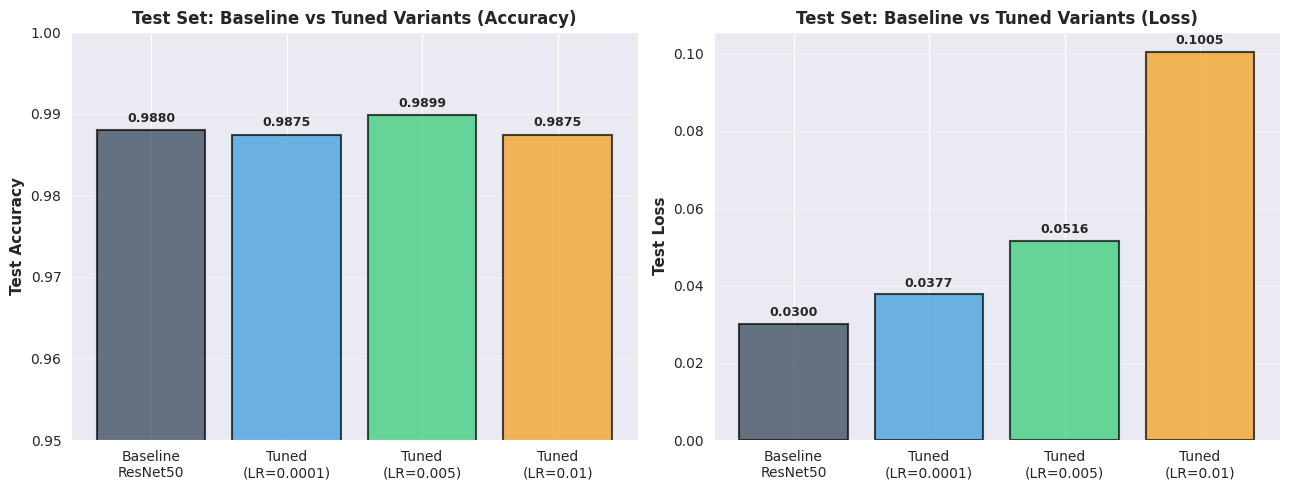

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models_tuned = ['Baseline\nResNet50', 'Tuned\n(LR=0.0001)', 'Tuned\n(LR=0.005)', 'Tuned\n(LR=0.01)']
test_accs_tuned = [baseline_test_acc, tuned_0001_test_acc, tuned_005_test_acc, tuned_01_test_acc]
test_losses_tuned = [baseline_test_loss, tuned_0001_test_loss, tuned_005_test_loss, tuned_01_test_loss]

colors_tuned = ['#2c3e50', '#3498db', '#2ecc71', '#f39c12']

bars1 = axes[0].bar(models_tuned, test_accs_tuned, color=colors_tuned, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
axes[0].set_title('Test Set: Baseline vs Tuned Variants (Accuracy)', fontsize=12, fontweight='bold')
axes[0].set_ylim([0.95, 1.0])
for bar, acc in zip(bars1, test_accs_tuned):
    axes[0].text(bar.get_x() + bar.get_width()/2, acc + 0.001,
                f'{acc:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')


bars2 = axes[1].bar(models_tuned, test_losses_tuned, color=colors_tuned, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Test Loss', fontsize=11, fontweight='bold')
axes[1].set_title('Test Set: Baseline vs Tuned Variants (Loss)', fontsize=12, fontweight='bold')
for bar, loss in zip(bars2, test_losses_tuned):
    axes[1].text(bar.get_x() + bar.get_width()/2, loss + 0.002,
                f'{loss:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Test results show negligible gains from LR tuning over the baseline. Baseline (LR=0.001) achieved 0.9880 accuracy; the best tuned variant (LR=0.005) reached 0.9899, an absolute gain of 0.0019 (= +0.19 percentage points). Other tuned runs were within a similar band. This supports the validation finding: with a frozen ResNet50 backbone, performance is largely insensitive to LR in this range. For deployment, the baseline configuration is preferred for simplicity and reproducibility.

### Pretrained vs scratch comparison

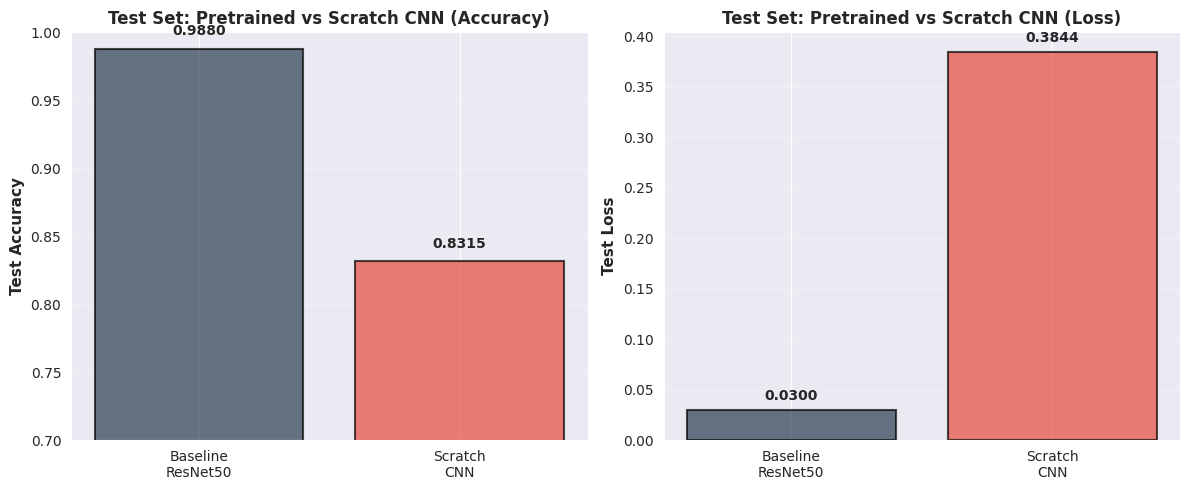

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models_scratch = ['Baseline\nResNet50', 'Scratch\nCNN']
test_accs_scratch = [baseline_test_acc, scratch_test_acc]
test_losses_scratch = [baseline_test_loss, scratch_test_loss]

colors_scratch = ['#2c3e50', '#e74c3c']

# Test Accuracy
bars1 = axes[0].bar(models_scratch, test_accs_scratch, color=colors_scratch, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
axes[0].set_title('Test Set: Pretrained vs Scratch CNN (Accuracy)', fontsize=12, fontweight='bold')
axes[0].set_ylim([0.7, 1.0])
for bar, acc in zip(bars1, test_accs_scratch):
    axes[0].text(bar.get_x() + bar.get_width()/2, acc + 0.01,
                f'{acc:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

# Test Loss
bars2 = axes[1].bar(models_scratch, test_losses_scratch, color=colors_scratch, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Test Loss', fontsize=11, fontweight='bold')
axes[1].set_title('Test Set: Pretrained vs Scratch CNN (Loss)', fontsize=12, fontweight='bold')
for bar, loss in zip(bars2, test_losses_scratch):
    axes[1].text(bar.get_x() + bar.get_width()/2, loss + 0.01,
                f'{loss:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

The pretrained ResNet50 substantially outperforms the scratch CNN: 98.8% vs 83.1% accuracy (≈15–16 percentage‑point gap). Test loss is also much lower for the pretrained model (≈0.03 vs ≈0.38), indicating more calibrated, confident predictions.


# Conclusions and future work

- Transfer learning dominates: a frozen ResNet50 achieves near‑99% accuracy; LR tuning around the default brings negligible gains.
- The scratch CNN learns but plateaus far below the pretrained model, likely limited by capacity and lack of pretraining.
- Grad‑CAM shows attention on facial regions; misclassifications arise from occlusions, unusual poses, and low resolution rather than class bias.

Next steps
- Unfreeze and fine‑tune upper ResNet layers with a lower LR; optionally use discriminative LRs.
- Explore stronger augmentation (random resize crop, CutMix/MixUp) and regularization; evaluate calibration (ECE) and confidence thresholds.
- Add early stopping and LR scheduling; try SGD+momentum vs Adam.
- Increase scratch model capacity or training epochs; consider transfer pretraining for scratch architecture.
- Validate on an external cats/dogs dataset to assess generalization.